In [1]:
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
import logging
import datetime
import time

from datetime import datetime

from pyspark.sql.functions import col, datediff
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

import calendar
import pandas as pd
import plotly.express as px
from pyspark.sql import SparkSession
from pyspark.sql.functions import concat, col
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from ipywidgets import interact, widgets
from matplotlib.dates import MonthLocator, DateFormatter
import geopandas as gpd
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
#from fbprophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
import plotly.graph_objects as go
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month
from sklearn.metrics.pairwise import euclidean_distances
from pyspark.sql.functions import year, month, sum as sum_
from scipy.spatial.distance import euclidean
from prophet import Prophet
from pyspark.sql.functions import col, countDistinct , desc , count , length
from pyspark.sql.functions import split, col, when
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, dayofmonth, last_day ,to_date, lit, isnull
from pyspark.sql.types import IntegerType
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from dateutil.relativedelta import relativedelta
from pyspark.sql.functions import date_format

from pyspark.sql.functions import col, coalesce, current_date, months_between, round
from pyspark.sql.functions import regexp_replace

import schedule
from pyspark.sql.functions import col, to_timestamp, date_format

import pyspark
import pandas as pd
import boto3
import sagemaker
import sagemaker.feature_store.feature_store as fs
import databricks.connect
from dateutil.relativedelta import relativedelta

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, root_mean_squared_error

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import plotly.graph_objects as go
from itertools import product
import random
import statsmodels.api as sm
import os

from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, months_between, current_date,expr
from pyspark.sql.functions import col, substr

import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from databricks.connect import DatabricksSession


# Get spark
spark = databricks.connect.DatabricksSession.builder.getOrCreate()

c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\pydantic\_internal\_fields.py:192: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[02/21/25 11:39:33] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=341468;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py\credentials.py]8;;\:]8;id=896750;file://c:\Users\gusta\AppData\Local\pypoetry\Cache\virtualenvs\ltv-novo-aF9Dy8BA-py3.10\lib\site-packages\botocore\credentials.py#1278\1278]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: C:\ProgramData\sagemaker\sagemaker\config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: C:\Users\gusta\AppData\Local\sagemaker\sagemaker\config.yaml


In [2]:
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")

In [3]:
ltv = spark.table("dev.dw_rok.tb_ltv")

In [4]:
ltv.show()
ltv.count()

+---------+--------------+-------+-----------+----------+-----------+--------------------+------------------+---------------+----------------+-------+-------------------+--------------+------------+-----------+-------------+-------------------+-----+----------+--------------------------------------+-----------------------------------+-----------------------------------------+---------------------------------------+--------------+-------+--------------------+----+---------------------+-------+
|contratos|     documento|cliente|data_inicio|data_final|max_conexao|data_primeiro_boleto|data_ultimo_boleto|boletos_gerados|total_valor_pago|receita|         tipo_saida|meses_contrato|meses_boleto|anos_boleto|anos_contrato|boleto_gerados_anos|churn|ano_inicio|diferenca_meses_inicio_primeiro_boleto|diferenca_meses_final_ultimo_boleto|classifica_diferenca_boleto_tempo_inicial|classifica_diferenca_boleto_tempo_final|      CNPJ_CPF|CNAE_RF|          Hierarquia|  uf|data_inicio_atividade|empresa|
+---

130225

In [5]:
tabela_nova_df = ltv.toPandas()

In [6]:
# Convertendo as colunas para datetime
tabela_nova_df['data_primeiro_boleto'] = pd.to_datetime(tabela_nova_df['data_primeiro_boleto'])
tabela_nova_df['data_inicio'] = pd.to_datetime(tabela_nova_df['data_inicio'])

# Filtrando os dados onde ambas as datas são maiores ou iguais a 2006
filtro = (tabela_nova_df['data_primeiro_boleto'].dt.year >= 2006) & (tabela_nova_df['data_inicio'].dt.year >= 2006)
tabela_nova_df_2006 = tabela_nova_df[filtro]

# Exibindo os resultados filtrados
print("Resultados filtrados:")
display(tabela_nova_df_2006.head())


Resultados filtrados:


,contratos,documento,cliente,data_inicio,data_final,max_conexao,data_primeiro_boleto,data_ultimo_boleto,boletos_gerados,total_valor_pago,...,diferenca_meses_inicio_primeiro_boleto,diferenca_meses_final_ultimo_boleto,classifica_diferenca_boleto_tempo_inicial,classifica_diferenca_boleto_tempo_final,CNPJ_CPF,CNAE_RF,Hierarquia,uf,data_inicio_atividade,empresa
0,1,00012212000199,435133,2019-04-12,2019-12-23,0,2019-05-01,2020-01-01,9,436.5,...,1,1,0 a 1 mês,0 a 1 mês,00012212000199,4781400,Comércio; Comércio varejista; Vestuário e aces...,SP,19940531,RedeOk
2,1,00071260000158,166252,2006-01-25,2008-06-30,-1,2006-02-01,2008-06-01,21,681.2,...,1,0,0 a 1 mês,0 a 1 mês,00071260000158,8640213,Serviços; Saúde,MT,19940519,RedeOk
3,1,00076958000166,436692,2019-06-04,2023-11-22,-1,2019-07-01,2023-11-01,53,3631.6,...,1,0,0 a 1 mês,0 a 1 mês,00076958000166,4751201,Comércio; Comércio varejista; Informática e co...,MT,19940526,RedeOk
4,1,00082998000110,423039,2018-01-18,2018-12-19,0,2018-02-01,2019-03-01,14,910.0,...,1,3,0 a 1 mês,2 a 5 meses,00082998000110,2930101,Indústria; Indústrias de Transformação; Automo...,PR,19940606,RedeOk
5,1,00108003000143,392329,2016-05-12,2019-02-28,-1,2016-06-01,2019-02-01,33,3039.0,...,1,0,0 a 1 mês,0 a 1 mês,00108003000143,4771701,Comércio; Comércio varejista; Farmacêuticos,TO,19940708,RedeOk


In [7]:
tabela_nova_df_2006.shape

(118012, 29)

## Tempo de Permanencia por Faixas

In [8]:
import plotly.graph_objects as go
import pandas as pd

def plotar_distribuicao_permanencia(sdf, coluna_anos_contrato="anos_contrato", coluna_anos_boleto="anos_boleto", coluna_tipo_saida="tipo_saida"):
    """
    Gera um gráfico de barras comparando a distribuição do tempo de permanência dos clientes cancelados
    para as colunas `anos_contrato` e `anos_boleto`.

    Parâmetros:
    sdf (DataFrame do Spark): DataFrame contendo as colunas de anos de contrato, anos de boleto e status de saída.
    coluna_anos_contrato (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_anos_boleto (str): Nome da coluna que contém a quantidade de anos do boleto.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    
    # Converter para Pandas e filtrar os clientes cancelados
    df_filtrado = sdf[sdf[coluna_tipo_saida] != "ATIVO"]

    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_filtrado[[coluna_anos_contrato, coluna_anos_boleto]].max().max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar colunas categóricas com os intervalos
    df_filtrado["faixa_permanencia_contrato"] = pd.cut(df_filtrado[coluna_anos_contrato], bins=bins, labels=labels, right=True)
    df_filtrado["faixa_permanencia_boleto"] = pd.cut(df_filtrado[coluna_anos_boleto], bins=bins, labels=labels, right=True)

    # Contar a frequência de cada faixa para ambas as colunas, garantindo que todas as categorias existam
    df_faixas_contrato = df_filtrado["faixa_permanencia_contrato"].value_counts().reindex(labels, fill_value=0).reset_index()
    df_faixas_contrato.columns = ["faixa_permanencia", "frequencia_contrato"]

    df_faixas_boleto = df_filtrado["faixa_permanencia_boleto"].value_counts().reindex(labels, fill_value=0).reset_index()
    df_faixas_boleto.columns = ["faixa_permanencia", "frequencia_boleto"]

    # Mesclar os dois DataFrames para ter faixas alinhadas
    df_faixas = pd.merge(df_faixas_contrato, df_faixas_boleto, on="faixa_permanencia", how="outer").fillna(0)

    # Ordenar as categorias corretamente
    df_faixas["faixa_permanencia"] = pd.Categorical(df_faixas["faixa_permanencia"], categories=labels, ordered=True)
    df_faixas = df_faixas.sort_values(by="faixa_permanencia")

    # Criar gráfico de barras lado a lado
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_faixas["faixa_permanencia"],
        y=df_faixas["frequencia_contrato"],
        name="Anos Contrato",
        marker_color="blue"
    ))

    fig.add_trace(go.Bar(
        x=df_faixas["faixa_permanencia"],
        y=df_faixas["frequencia_boleto"],
        name="Anos Boleto",
        marker_color="red"
    ))

    # Configurar layout do gráfico
    fig.update_layout(
        title="Distribuição do Tempo de Permanência dos Clientes Cancelados por Faixa (anos)",
        xaxis_title="Faixa de Tempo de Permanência (anos)",
        yaxis_title="Frequência",
        barmode="group",  # Coloca as barras lado a lado
        template="plotly_white"
    )

    # Exibir gráfico
    fig.show()


In [9]:
plotar_distribuicao_permanencia(tabela_nova_df_2006, coluna_anos_contrato="anos_contrato", coluna_anos_boleto="anos_boleto", coluna_tipo_saida="tipo_saida")

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\614927708.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["faixa_permanencia_contrato"] = pd.cut(df_filtrado[coluna_anos_contrato], bins=bins, labels=labels, right=True)
C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\614927708.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["faixa_permanencia_boleto"] = pd.cut(df_filtrado[coluna_anos_boleto], bins=bins, labels=labels, right=True)


In [16]:
import plotly.graph_objects as go
import pandas as pd

def plotar_distribuicao_permanencia(sdf, coluna_anos_contrato="anos_contrato", coluna_anos_boleto="anos_boleto", coluna_tipo_saida="tipo_saida"):
    """
    Gera um gráfico de barras comparando a distribuição do tempo de permanência dos clientes cancelados
    para as colunas `anos_contrato` e `anos_boleto`.

    Parâmetros:
    sdf (DataFrame do Spark): DataFrame contendo as colunas de anos de contrato, anos de boleto e status de saída.
    coluna_anos_contrato (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_anos_boleto (str): Nome da coluna que contém a quantidade de anos do boleto.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    
    # Converter para Pandas e filtrar os clientes cancelados
    df_filtrado = sdf[sdf[coluna_tipo_saida] != "ATIVO"]

    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_filtrado[[coluna_anos_contrato, coluna_anos_boleto]].max().max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar colunas categóricas com os intervalos
    df_filtrado["faixa_permanencia_contrato"] = pd.cut(df_filtrado[coluna_anos_contrato], bins=bins, labels=labels, right=True)
    df_filtrado["faixa_permanencia_boleto"] = pd.cut(df_filtrado[coluna_anos_boleto], bins=bins, labels=labels, right=True)

    # Contar a frequência de cada faixa para ambas as colunas, garantindo que todas as categorias existam
    df_faixas_contrato = df_filtrado["faixa_permanencia_contrato"].value_counts().reindex(labels, fill_value=0).reset_index()
    df_faixas_contrato.columns = ["faixa_permanencia", "frequencia_contrato"]

    df_faixas_boleto = df_filtrado["faixa_permanencia_boleto"].value_counts().reindex(labels, fill_value=0).reset_index()
    df_faixas_boleto.columns = ["faixa_permanencia", "frequencia_boleto"]

    # Calcular o total de registros para o cálculo de porcentagem
    total_contrato = df_faixas_contrato["frequencia_contrato"].sum()
    total_boleto = df_faixas_boleto["frequencia_boleto"].sum()

    # Calcular as porcentagens para cada faixa e arredondar para uma casa decimal
    df_faixas_contrato["porcentagem_contrato"] = (df_faixas_contrato["frequencia_contrato"] / total_contrato) * 100
    df_faixas_boleto["porcentagem_boleto"] = (df_faixas_boleto["frequencia_boleto"] / total_boleto) * 100

    df_faixas_contrato["porcentagem_contrato"] = df_faixas_contrato["porcentagem_contrato"].round(1)
    df_faixas_boleto["porcentagem_boleto"] = df_faixas_boleto["porcentagem_boleto"].round(1)

    # Mesclar os dois DataFrames para ter faixas alinhadas
    df_faixas = pd.merge(df_faixas_contrato[["faixa_permanencia", "porcentagem_contrato"]],
                         df_faixas_boleto[["faixa_permanencia", "porcentagem_boleto"]],
                         on="faixa_permanencia", how="outer").fillna(0)

    # Ordenar as categorias corretamente
    df_faixas["faixa_permanencia"] = pd.Categorical(df_faixas["faixa_permanencia"], categories=labels, ordered=True)
    df_faixas = df_faixas.sort_values(by="faixa_permanencia")

    # Exibir a tabela com porcentagens
    display(df_faixas)

    # Criar gráfico de barras lado a lado
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=df_faixas["faixa_permanencia"],
        y=df_faixas["porcentagem_contrato"],
        name="Anos Contrato",
        marker_color="blue"
    ))

    fig.add_trace(go.Bar(
        x=df_faixas["faixa_permanencia"],
        y=df_faixas["porcentagem_boleto"],
        name="Anos Boleto",
        marker_color="red"
    ))

    # Configurar layout do gráfico
    fig.update_layout(
        title="Distribuição do Tempo de Permanência dos Clientes Cancelados por Faixa (anos)",
        xaxis_title="Faixa de Tempo de Permanência (anos)",
        yaxis_title="Porcentagem (%)",
        barmode="group",  # Coloca as barras lado a lado
        template="plotly_white"
    )

    # Exibir gráfico
    fig.show()


In [17]:
plotar_distribuicao_permanencia(tabela_nova_df_2006, coluna_anos_contrato="anos_contrato", coluna_anos_boleto="anos_boleto", coluna_tipo_saida="tipo_saida")

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\631749961.py:37: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\631749961.py:38: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,faixa_permanencia,porcentagem_contrato,porcentagem_boleto
0,0-1 ano,26.8,32.3
1,1-2 anos,22.2,21.5
3,2-3 anos,12.9,12.3
4,3-4 anos,9.1,8.9
5,4-5 anos,7.1,6.4
6,5-6 anos,5.2,4.9
7,6-8 anos,7.1,6.4
8,8-10 anos,4.7,3.6
2,10+ anos,5.0,3.8


## Classificação diferença Datas Boletos e Datas Cadastro

In [10]:
import pandas as pd

# Supondo que tabela_nova_df_2006 seja um DataFrame do Pandas
# Contar a quantidade de cada faixa no Pandas
count_inicial_pdf = tabela_nova_df_2006.groupby("classifica_diferenca_boleto_tempo_inicial").size().reset_index(name='count')
count_final_pdf = tabela_nova_df_2006.groupby("classifica_diferenca_boleto_tempo_final").size().reset_index(name='count')

# Adicionar a linha do total
total_inicial = count_inicial_pdf['count'].sum()
total_final = count_final_pdf['count'].sum()

# Adicionar o total ao DataFrame
count_inicial_pdf = pd.concat([
    count_inicial_pdf,
    pd.DataFrame([{"classifica_diferenca_boleto_tempo_inicial": "Total", "count": total_inicial}])
], ignore_index=True)

count_final_pdf = pd.concat([
    count_final_pdf,
    pd.DataFrame([{"classifica_diferenca_boleto_tempo_final": "Total", "count": total_final}])
], ignore_index=True)

# Ordenar os dados pela quantidade em ordem decrescente (do maior para o menor)
count_inicial_pdf = count_inicial_pdf.sort_values(by="count", ascending=False)
count_final_pdf = count_final_pdf.sort_values(by="count", ascending=False)

# Exibir os DataFrames resultantes
import plotly.graph_objects as go

# Criar gráfico interativo para classifica_diferenca_boleto_tempo_inicial
fig_inicial = go.Figure()
fig_inicial.add_trace(go.Bar(
    x=count_inicial_pdf["classifica_diferenca_boleto_tempo_inicial"],
    y=count_inicial_pdf["count"],
    marker_color='blue'
))
fig_inicial.update_layout(
    title="Distribuição - Classificação Diferença Data Primeiro Boleto e Data Inicial Cadastro",
    xaxis_title="Faixa",
    yaxis_title="Quantidade",
    xaxis=dict(categoryorder="total descending")
)
fig_inicial.show()

# Criar gráfico interativo para classifica_diferenca_boleto_tempo_final
fig_final = go.Figure()
fig_final.add_trace(go.Bar(
    x=count_final_pdf["classifica_diferenca_boleto_tempo_final"],
    y=count_final_pdf["count"],
    marker_color='red'
))
fig_final.update_layout(
    title="Distribuição - Classificação Diferença Data Ultimo Boleto e Data Final Cadastro",
    xaxis_title="Faixa",
    yaxis_title="Quantidade",
    xaxis=dict(categoryorder="total descending")
)
fig_final.show()

# Exibir os DataFrames de contagem
display(count_inicial_pdf)
display(count_final_pdf)


,classifica_diferenca_boleto_tempo_inicial,count
5,Total,118012
0,0 a 1 mês,96268
2,2 a 5 meses,12347
4,Maior que 24 meses,4417
3,6 a 12 meses,2780
1,13 a 24 meses,2200


,classifica_diferenca_boleto_tempo_final,count
5,Total,118012
0,0 a 1 mês,73298
2,2 a 5 meses,20607
3,6 a 12 meses,11593
1,13 a 24 meses,6261
4,Maior que 24 meses,6253


In [18]:
import pandas as pd

# Supondo que tabela_nova_df_2006 seja um DataFrame do Pandas
# Contar a quantidade de cada faixa no Pandas
count_inicial_pdf = tabela_nova_df_2006.groupby("classifica_diferenca_boleto_tempo_inicial").size().reset_index(name='count')
count_final_pdf = tabela_nova_df_2006.groupby("classifica_diferenca_boleto_tempo_final").size().reset_index(name='count')

# Adicionar a linha do total
total_inicial = count_inicial_pdf['count'].sum()
total_final = count_final_pdf['count'].sum()

# Calcular as porcentagens
count_inicial_pdf['percentage'] = (count_inicial_pdf['count'] / total_inicial) * 100
count_final_pdf['percentage'] = (count_final_pdf['count'] / total_final) * 100

# Arredondar as porcentagens para 0 casas decimais
count_inicial_pdf['percentage'] = count_inicial_pdf['percentage'].round(0)
count_final_pdf['percentage'] = count_final_pdf['percentage'].round(0)

# Adicionar o total ao DataFrame
count_inicial_pdf = pd.concat([ 
    count_inicial_pdf[['classifica_diferenca_boleto_tempo_inicial', 'percentage']],  # Selecionar apenas as colunas necessárias
    pd.DataFrame([{"classifica_diferenca_boleto_tempo_inicial": "Total", "percentage": 100}])
], ignore_index=True)

count_final_pdf = pd.concat([ 
    count_final_pdf[['classifica_diferenca_boleto_tempo_final', 'percentage']],  # Selecionar apenas as colunas necessárias
    pd.DataFrame([{"classifica_diferenca_boleto_tempo_final": "Total", "percentage": 100}])
], ignore_index=True)

# Ordenar os dados pela porcentagem em ordem decrescente (do maior para o menor)
count_inicial_pdf = count_inicial_pdf.sort_values(by="percentage", ascending=False)
count_final_pdf = count_final_pdf.sort_values(by="percentage", ascending=False)

# Exibir os DataFrames resultantes (somente com porcentagens)
import plotly.graph_objects as go

# Criar gráfico interativo para classifica_diferenca_boleto_tempo_inicial
fig_inicial = go.Figure()
fig_inicial.add_trace(go.Bar(
    x=count_inicial_pdf["classifica_diferenca_boleto_tempo_inicial"],
    y=count_inicial_pdf["percentage"],
    marker_color='blue'
))
fig_inicial.update_layout(
    title="Distribuição - Classificação Diferença Data Primeiro Boleto e Data Inicial Cadastro",
    xaxis_title="Faixa",
    yaxis_title="Porcentagem (%)",
    xaxis=dict(categoryorder="total descending")
)
fig_inicial.show()

# Criar gráfico interativo para classifica_diferenca_boleto_tempo_final
fig_final = go.Figure()
fig_final.add_trace(go.Bar(
    x=count_final_pdf["classifica_diferenca_boleto_tempo_final"],
    y=count_final_pdf["percentage"],
    marker_color='red'
))
fig_final.update_layout(
    title="Distribuição - Classificação Diferença Data Ultimo Boleto e Data Final Cadastro",
    xaxis_title="Faixa",
    yaxis_title="Porcentagem (%)",
    xaxis=dict(categoryorder="total descending")
)
fig_final.show()

# Exibir os DataFrames de porcentagem
display(count_inicial_pdf)
display(count_final_pdf)


,classifica_diferenca_boleto_tempo_inicial,percentage
5,Total,100.0
0,0 a 1 mês,82.0
2,2 a 5 meses,10.0
4,Maior que 24 meses,4.0
1,13 a 24 meses,2.0
3,6 a 12 meses,2.0


,classifica_diferenca_boleto_tempo_final,percentage
5,Total,100.0
0,0 a 1 mês,62.0
2,2 a 5 meses,17.0
3,6 a 12 meses,10.0
1,13 a 24 meses,5.0
4,Maior que 24 meses,5.0


## Tempo média de permanencia por Inicio de contrato

In [20]:
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime

def analisar_permanencia_comparada(tabela_sdf):
    """
    Analisa e compara o tempo de permanência dos contratos baseados na data de início e na data do primeiro boleto.

    Parâmetros:
    tabela_sdf (Spark DataFrame): DataFrame do Spark contendo 'data_inicio', 'anos_contrato', 
                                  'data_primeiro_boleto' e 'anos_boleto'.

    Retorno:
    fig (plotly.graph_objects.Figure): Gráfico interativo comparando os tempos de permanência.
    """

    # Filtrar e selecionar os contratos cancelados em Pandas
    df_contratos = tabela_nova_df_2006[tabela_nova_df_2006["tipo_saida"] != "ATIVO"] \
    [["data_inicio", "anos_contrato", "data_primeiro_boleto", "anos_boleto"]]



    # Converter colunas de data para datetime
    df_contratos["data_inicio"] = pd.to_datetime(df_contratos["data_inicio"])
    df_contratos["data_primeiro_boleto"] = pd.to_datetime(df_contratos["data_primeiro_boleto"])

    # Criar colunas com o ano do contrato e o ano do primeiro boleto
    df_contratos["ano_inicio"] = df_contratos["data_inicio"].dt.year
    df_contratos["ano_primeiro_boleto"] = df_contratos["data_primeiro_boleto"].dt.year

    # Obter o ano atual
    ano_atual = datetime.today().year

    # Calcular estatísticas por ano para os contratos
    estatisticas_contratos = df_contratos.groupby("ano_inicio")["anos_contrato"].agg(["median", "mean"]).reset_index()
    estatisticas_contratos["tempo_maximo_possivel"] = ano_atual - estatisticas_contratos["ano_inicio"]

    # Calcular estatísticas por ano para os boletos
    estatisticas_boletos = df_contratos.groupby("ano_primeiro_boleto")["anos_boleto"].agg(["median", "mean"]).reset_index()
    estatisticas_boletos["tempo_maximo_possivel"] = ano_atual - estatisticas_boletos["ano_primeiro_boleto"]

    # Criar gráfico interativo
    fig = go.Figure()

 

    fig.add_trace(go.Scatter(
        x=estatisticas_contratos["ano_inicio"],
        y=estatisticas_contratos["mean"],
        mode="lines+markers",
        name="Média Contratos",
        line=dict(color="green")
    ))

  


    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["mean"],
        mode="lines+markers",
        name="Média Boletos",
        line=dict(color="orange")
    ))

    fig.add_trace(go.Scatter(
        x=estatisticas_boletos["ano_primeiro_boleto"],
        y=estatisticas_boletos["tempo_maximo_possivel"],
        mode="lines",
        name="Tempo Máximo ",
        line=dict(color="brown", dash="dash")
    ))

    # Layout do gráfico
    fig.update_layout(
        title="Comparação do Tempo de Permanência por Início de Contrato: Contratos vs. Boletos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Permanência (anos)",
        showlegend=True,
        xaxis=dict(
            dtick=1,
            tickmode='linear'
        )
    )

    return fig


analisar_permanencia_comparada(tabela_nova_df_2006)


### Taxa de Churn por Inicio de contrato

In [23]:
from pyspark.sql import functions as F
import plotly.graph_objects as go

def calcular_taxa_churn_anual_datas(sdf_final):
    """
    Calcula a taxa de churn anual com base no ano de início do contrato e gera um gráfico interativo.
    
    Parâmetros:
    sdf_final (DataFrame): DataFrame do Spark contendo as colunas 'data_inicio' e 'data_ultimo_boleto'.
    
    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    # Agrupar os dados por 'ano_inicio' e calcular as métricas necessárias
    df_churn_anual = sdf_final.groupby('ano_inicio').agg(
        total_clientes=('ano_inicio', 'size'),  # Contagem total de clientes
        contratos_cancelados=('data_ultimo_boleto', lambda x: (x.notna()).sum())  # Contagem de contratos cancelados
    ).reset_index()

    # Calcular a taxa de churn
    df_churn_anual['taxa_churn'] = (df_churn_anual['contratos_cancelados'] / df_churn_anual['total_clientes']) * 100

    # Ordenar pelo 'ano_inicio'
    df_churn_anual = df_churn_anual.sort_values(by="ano_inicio").reset_index(drop=True)
    
    # Criar gráfico interativo com Plotly
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=df_churn_anual["ano_inicio"],
        y=df_churn_anual["taxa_churn"],
        marker_color="red",
        name="Taxa de Churn (%)"
    ))
    
    # Ajustes de layout
    fig.update_layout(
        title="Taxa de Churn por Inicio de Contrato (Boletos)",
        xaxis_title="Ano de Início do Contrato",
        yaxis_title="Taxa de Churn (%)",
        template="plotly_white",
        xaxis=dict(tickmode="linear")
    )
    
    # Exibir o gráfico
    fig.show()


calcular_taxa_churn_anual_datas(tabela_nova_df_2006)

## Porcentagem de tempo de permanecia maior que 1, 2 , 3 e 4 anos em relação ao inicio de contrato

In [99]:
import pandas as pd
import plotly.graph_objects as go

def plotar_retencao_clientes_por_ano(df, ano=1):
    """
    Gera uma tabela e um gráfico de barras mostrando a retenção de clientes com base no tempo de permanência,
    comparando clientes com permanência maior ou igual a 'ano' anos e menor que 'ano' anos.

    Parâmetros:
    df (DataFrame do Pandas): DataFrame contendo as informações de clientes e seus boletos.
    ano (int): O número de anos para comparar os clientes com maior ou menor permanência.
    
    Retorno:
    None (exibe a tabela e o gráfico interativo com Plotly)
    """
    
    # Converter a coluna 'data_primeiro_boleto' para datetime
    df['data_primeiro_boleto'] = pd.to_datetime(df['data_primeiro_boleto'])

    # Criar a coluna do ano do primeiro boleto
    df['ano_primeiro_boleto'] = df['data_primeiro_boleto'].dt.year

    # Agrupar por ano e calcular total, porcentagens de >ano e <ano
    tabela = df.groupby('ano_primeiro_boleto').agg(
        total_registros=('anos_boleto', 'count'),
        porcentagem_maior_ano=('anos_boleto', lambda x: (x >= ano).mean() * 100),
        porcentagem_menor_ano=('anos_boleto', lambda x: (x < ano).mean() * 100)
    ).reset_index()

    # Exibir a tabela
    display(tabela)

    # Criar gráfico para mostrar os tempos > ano e < ano
    fig = go.Figure()

    # Adicionar barras para os clientes com >= ano anos
    fig.add_trace(go.Bar(
        x=tabela['ano_primeiro_boleto'].astype(str),  
        y=tabela['porcentagem_maior_ano'], 
        name=f">= {ano} anos", 
        marker_color='green'
    ))

    # Adicionar barras para os clientes com < ano ano (empilhadas)
    fig.add_trace(go.Bar(
        x=tabela['ano_primeiro_boleto'].astype(str),  
        y=tabela['porcentagem_menor_ano'], 
        name=f"< {ano} ano", 
        marker_color='red'
    ))

    # Configurações do layout
    fig.update_layout(
        title=f"Retenção de Clientes por Ano do Primeiro Boleto (>= {ano} ano vs < {ano} ano)",
        xaxis_title="Ano do Primeiro Boleto",
        yaxis_title="Porcentagem (%)",
        xaxis=dict(
            type='category',
            tickmode='array',
            tickvals=tabela['ano_primeiro_boleto'].astype(str),
            ticktext=[str(ano) for ano in tabela['ano_primeiro_boleto']]
        ),
        barmode='stack',
        legend_title="Tempo de Permanência"
    )

    # Exibir o gráfico
    fig.show()


In [104]:
plotar_retencao_clientes_por_ano(tabela_nova_df_2006, ano=2)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2778583481.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2778583481.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,ano_primeiro_boleto,total_registros,porcentagem_maior_ano,porcentagem_menor_ano
0,2006,3404,52.438308,47.561692
1,2007,4359,60.564350,39.435650
2,2008,9525,55.128609,44.871391
3,2009,10765,57.138876,42.861124
4,2010,7660,72.010444,27.989556
5,2011,8190,62.393162,37.606838
6,2012,9616,51.341514,48.658486
7,2013,10749,50.497721,49.502279
8,2014,10597,47.277531,52.722469
9,2015,8540,46.088993,53.911007


Distribuição do Tempo de Permanência para Clientes que Começaram em 2024:
anos_boleto
0.08    108
0.17    136
0.25    198
0.33    196
0.42    152
0.50    120
0.58    157
0.67    136
0.75    164
0.83    134
0.92    130
1.00    120
1.08     94
1.17     53
Name: count, dtype: int64


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3519399294.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3519399294.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



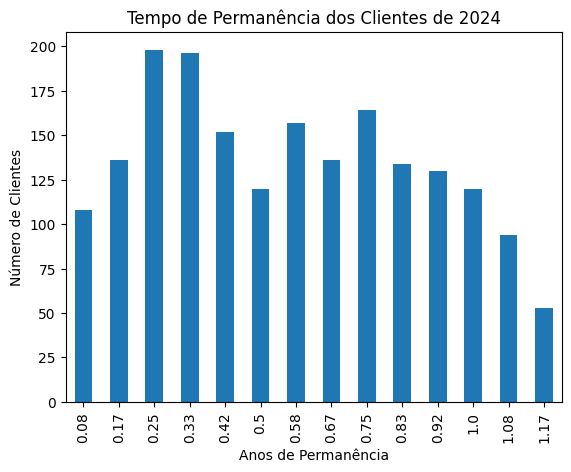

In [113]:
import pandas as pd

def verificar_clientes_2024(df):
    """
    Filtra clientes cujo primeiro boleto foi emitido em 2024 e exibe a distribuição dos anos de permanência.

    Parâmetros:
    df (DataFrame do Pandas): DataFrame contendo as informações de clientes e seus boletos.
    
    Retorno:
    None (exibe a contagem dos anos de permanência para clientes iniciados em 2024)
    """

    # Converter a coluna 'data_primeiro_boleto' para datetime, se ainda não estiver
    df['data_primeiro_boleto'] = pd.to_datetime(df['data_primeiro_boleto'])

    # Criar a coluna do ano do primeiro boleto
    df['ano_primeiro_boleto'] = df['data_primeiro_boleto'].dt.year

    # Filtrar clientes que começaram em 2024
    df_2024 = df[df['ano_primeiro_boleto'] == 2024]

    # Contar quantos clientes têm cada tempo de permanência
    distribuicao_anos = df_2024['anos_boleto'].value_counts().sort_index()

    # Exibir os resultados
    print("Distribuição do Tempo de Permanência para Clientes que Começaram em 2024:")
    print(distribuicao_anos)

    # Se quiser visualizar os dados em um gráfico:
    distribuicao_anos.plot(kind='bar', title="Tempo de Permanência dos Clientes de 2024", ylabel="Número de Clientes", xlabel="Anos de Permanência")

verificar_clientes_2024(tabela_nova_df_2006)

In [112]:
import pandas as pd

def porcentagem_clientes_2024(df):
    """
    Calcula a porcentagem de clientes que começaram em 2024 e permaneceram por 2 anos ou mais.

    Parâmetros:
    df (DataFrame do Pandas): DataFrame contendo as informações de clientes e seus boletos.
    
    Retorno:
    Exibe a porcentagem de clientes com 2 anos ou mais de permanência.
    """

    # Converter a coluna 'data_primeiro_boleto' para datetime
    df['data_primeiro_boleto'] = pd.to_datetime(df['data_primeiro_boleto'])

    # Criar a coluna do ano do primeiro boleto
    df['ano_primeiro_boleto'] = df['data_primeiro_boleto'].dt.year

    # Filtrar clientes que começaram em 2024
    df_2024 = df[df['ano_primeiro_boleto'] == 2023]

    # Calcular o total de clientes que começaram em 2024
    total_clientes_2024 = len(df_2024)

    if total_clientes_2024 == 0:
        print("Nenhum cliente começou em 2024.")
        return

    # Calcular quantos clientes têm 2 anos ou mais de permanência
    clientes_2_anos_ou_mais = df_2024[df_2024['anos_boleto'] >= 2]

    # Calcular a porcentagem
    porcentagem = (len(clientes_2_anos_ou_mais) / total_clientes_2024) * 100

    # Exibir o resultado
    print(f"Porcentagem de clientes de 2024 com 2 anos ou mais de permanência: {porcentagem:.2f}%")


porcentagem_clientes_2024(tabela_nova_df_2006)

Porcentagem de clientes de 2024 com 2 anos ou mais de permanência: 7.15%


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2547824543.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2547824543.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Analise de sobrevivencia

In [36]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter

def analisar_sobrevivencia_comparada_boletos(df):
    resultados = {"Ano": [], "Kaplan-Meier": [], "Weibull": [], "Cox": []}
    
    
    df["data_primeiro_boleto"] = pd.to_datetime(df["data_primeiro_boleto"])
    
    for ano_filtro in range(2015, 2025):
        print(f"Agora rodando para o ano {ano_filtro}...")
        
        
        df_filtrado = df[(df['data_primeiro_boleto'].dt.year >= ano_filtro)]
        
        df_filtrado["anos_boleto"] = df_filtrado["anos_boleto"].astype(float)
        df_filtrado["churn"] = df_filtrado["churn"].astype(int)
        
        if df_filtrado.empty:
            continue
        
        resultados["Ano"].append(ano_filtro)
        
        # Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        resultados["Kaplan-Meier"].append(tempo_km)
        
        # Weibull
        wf = WeibullFitter()
        wf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_weibull = wf.lambda_ * np.math.gamma(1 + 1 / wf.rho_)
        resultados["Weibull"].append(tempo_weibull)
        
        # Cox
        colunas_cox = ["anos_boleto", "churn"]
        if all(col in df_filtrado.columns for col in colunas_cox):
            df_cox = df_filtrado[colunas_cox].dropna()
            if not df_cox.empty:
                cph = CoxPHFitter()
                cph.fit(df_cox, duration_col="anos_boleto", event_col="churn")
                tempo_cox = cph.predict_expectation(df_cox).mean()
                resultados["Cox"].append(tempo_cox)
            else:
                resultados["Cox"].append(None)
        else:
            resultados["Cox"].append(None)
    
    df_resultados = pd.DataFrame(resultados)
    
    # Plotando gráfico
    fig = go.Figure()
    #fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Kaplan-Meier"],
                            # mode="lines+markers", name="Kaplan-Meier", line=dict(color="blue")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Weibull"],
                             mode="lines+markers", name="Weibull", line=dict(color="red")))
    #fig.add_trace(go.Scatter(x=df_resultados["Ano"].astype(str), y=df_resultados["Cox"],
                            # mode="lines+markers", name="Cox", line=dict(color="green")))
    fig.update_layout(
        title="Tempo de Vida Esperado (Weibull) -  Boletos",
        xaxis_title="Ano de Início",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Modelos"
    )
    fig.show()
    
    return df_resultados


In [37]:
analisar_sobrevivencia_comparada_boletos(tabela_nova_df_2006)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Agora rodando para o ano 2015...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o ano 2016...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



...

Agora rodando para o ano 2021...
Agora rodando para o ano 2022...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\18110278

Agora rodando para o ano 2023...
Agora rodando para o ano 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:35: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1811027899.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\18110278

,Ano,Kaplan-Meier,Weibull,Cox
0,2015,3.089348,3.412359,3.055263
1,2016,3.027720,3.422157,2.990735
2,2017,2.963036,3.474139,2.923006
3,2018,2.683461,3.145138,2.641114
4,2019,2.536109,3.083721,2.489689
5,2020,2.319769,2.886508,2.269204
6,2021,2.101775,2.750726,2.045355
7,2022,1.794617,2.481563,1.732826
8,2023,1.397922,2.191158,1.331022
9,2024,0.799917,1.244009,0.731259


### Analise Sobreviencia Janela Móvel

In [42]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from lifelines import KaplanMeierFitter, WeibullFitter, CoxPHFitter

def analisar_sobrevivencia_comparada_boletos(df, janela_movel=3, ano_inicio=2015, ano_fim=2024):
    resultados = {"Ano": [], "Kaplan-Meier": [], "Weibull": [], "Cox": []}
    
    df["data_inicio"] = pd.to_datetime(df["data_inicio"])
    df["data_primeiro_boleto"] = pd.to_datetime(df["data_primeiro_boleto"])
    
    for ano_filtro in range(ano_inicio, ano_fim - janela_movel + 1):  
        print(f"Agora rodando para o período {ano_filtro} - {ano_filtro + janela_movel - 1}...")

        # Filtra os dados dentro da janela móvel
        df_filtrado = df[(df['data_primeiro_boleto'].dt.year >= ano_filtro) & 
                         (df['data_primeiro_boleto'].dt.year < ano_filtro + janela_movel)]
        
        df_filtrado["anos_boleto"] = df_filtrado["anos_boleto"].astype(float)
        df_filtrado["churn"] = df_filtrado["churn"].astype(int)
        
        if df_filtrado.empty:
            continue
        
        resultados["Ano"].append(f"{ano_filtro}-{ano_filtro + janela_movel - 1}")
        
        # Kaplan-Meier
        kmf = KaplanMeierFitter()
        kmf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_km = np.trapz(kmf.survival_function_["KM_estimate"], kmf.survival_function_.index)
        resultados["Kaplan-Meier"].append(tempo_km)
        
        # Weibull
        wf = WeibullFitter()
        wf.fit(df_filtrado["anos_boleto"], event_observed=df_filtrado["churn"])
        tempo_weibull = wf.lambda_ * np.math.gamma(1 + 1 / wf.rho_)
        resultados["Weibull"].append(tempo_weibull)
        
        # Cox
        colunas_cox = ["anos_boleto", "churn"]
        if all(col in df_filtrado.columns for col in colunas_cox):
            df_cox = df_filtrado[colunas_cox].dropna()
            if not df_cox.empty:
                cph = CoxPHFitter()
                cph.fit(df_cox, duration_col="anos_boleto", event_col="churn")
                tempo_cox = cph.predict_expectation(df_cox).mean()
                resultados["Cox"].append(tempo_cox)
            else:
                resultados["Cox"].append(None)
        else:
            resultados["Cox"].append(None)
    
    df_resultados = pd.DataFrame(resultados)
    
    # Plotando gráfico
    fig = go.Figure()
    #fig.add_trace(go.Scatter(x=df_resultados["Ano"], y=df_resultados["Kaplan-Meier"],
                             #mode="lines+markers", name="Kaplan-Meier", line=dict(color="blue")))
    fig.add_trace(go.Scatter(x=df_resultados["Ano"], y=df_resultados["Weibull"],
                             mode="lines+markers", name="Weibull", line=dict(color="red")))
    #fig.add_trace(go.Scatter(x=df_resultados["Ano"], y=df_resultados["Cox"],
                             #mode="lines+markers", name="Cox", line=dict(color="green")))
    fig.update_layout(
        title="Tempo de Vida Esperado ( Weibull- Janela Móvel) Boletos",
        xaxis_title="Período (Janela Móvel)",
        yaxis_title="Tempo de Vida Esperado (anos)",
        template="plotly_white",
        legend_title="Modelos"
    )
    fig.show()
    
    return df_resultados


In [43]:
analisar_sobrevivencia_comparada_boletos(tabela_nova_df_2006, janela_movel=3, ano_inicio=2015, ano_fim=2025)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

Agora rodando para o período 2015 - 2017...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o período 2016 - 2018...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



...

Agora rodando para o período 2021 - 2023...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o período 2022 - 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



,Ano,Kaplan-Meier,Weibull,Cox
0,2015-2017,3.132291,3.590499,3.098152
1,2016-2018,3.101234,3.658110,3.064195
2,2017-2019,3.063057,3.777941,3.022879
3,2018-2020,2.676219,3.284399,2.635765
4,2019-2021,2.535980,3.229472,2.490945
5,2020-2022,2.334017,3.019698,2.284191
6,2021-2023,2.176457,2.882400,2.118062
7,2022-2024,1.799384,2.478735,1.737327


In [44]:
analisar_sobrevivencia_comparada_boletos(tabela_nova_df_2006, janela_movel=3, ano_inicio=2006, ano_fim=2025)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

Agora rodando para o período 2006 - 2008...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



Agora rodando para o período 2007 - 2009...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



...

Agora rodando para o período 2021 - 2023...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Agora rodando para o período 2022 - 2024...


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\802459825.py:36: DeprecationWarning:

`np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`



,Ano,Kaplan-Meier,Weibull,Cox
0,2006-2008,4.286312,4.426914,4.259413
1,2007-2009,4.154401,4.315376,4.133818
2,2008-2010,4.177016,4.337211,4.151380
3,2009-2011,4.126200,4.293043,4.095869
4,2010-2012,3.990494,4.163147,3.957426
5,2011-2013,3.594688,3.793273,3.564624
6,2012-2014,3.288228,3.525939,3.260996
7,2013-2015,3.166745,3.443811,3.135675
8,2014-2016,3.044792,3.382401,3.013553
9,2015-2017,3.132291,3.590499,3.098152


## Empresas da Rok

In [45]:
import pandas as pd
import plotly.express as px

def plot_churn_distribution(df):
    """
    Gera dois gráficos de barras:
    1. Distribuição absoluta de churn por empresa e ano do primeiro boleto.
    2. Distribuição percentual de churn por empresa e ano do primeiro boleto.
    
    Parâmetros:
    df (pd.DataFrame): DataFrame contendo as colunas 'empresa', 'churn' e 'ano_primeiro_boleto'.
    
    Retorna:
    None (exibe os gráficos diretamente).
    """
    
    # Criar a contagem agrupada
    tabela_contagem = df.groupby(['empresa', 'churn', 'ano_primeiro_boleto']).size().reset_index(name='quantidade')

    # Gráfico 1: Contagem absoluta
    fig = px.bar(
        tabela_contagem,
        x='ano_primeiro_boleto',
        y='quantidade',
        color='churn',
        facet_col='empresa',
        barmode='stack',
        title="Distribuição de Churn por Empresa e Ano do Primeiro Boleto",
        labels={'ano_primeiro_boleto': 'Ano do Primeiro Boleto', 'quantidade': 'Quantidade', 'churn': 'Churn'}
    )

    # Configurar escalas independentes para cada subplot
    fig.update_yaxes(matches=None)

    # Melhorar layout
    fig.update_layout(
        height=500,
        width=1200,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    # Exibir o gráfico
    fig.show()

    # Criar gráfico normalizado por percentual
    totais = tabela_contagem.groupby(['empresa', 'ano_primeiro_boleto'])['quantidade'].sum().reset_index()
    totais.rename(columns={'quantidade': 'total'}, inplace=True)

    # Juntar com a tabela original e calcular o percentual
    tabela_normalizada = pd.merge(tabela_contagem, totais, on=['empresa', 'ano_primeiro_boleto'])
    tabela_normalizada['percentual'] = tabela_normalizada['quantidade'] / tabela_normalizada['total'] * 100

    # Gráfico 2: Distribuição percentual
    fig_norm = px.bar(
        tabela_normalizada,
        x='ano_primeiro_boleto',
        y='percentual',
        color='churn',
        facet_col='empresa',
        barmode='stack',
        title="Distribuição Percentual de Churn por Empresa e Ano do Primeiro Boleto",
        labels={'ano_primeiro_boleto': 'Ano do Primeiro Boleto', 'percentual': '% de Clientes', 'churn': 'Churn'}
    )

    # Configurar escala de 0 a 100%
    fig_norm.update_yaxes(range=[0, 100])

    # Melhorar layout
    fig_norm.update_layout(
        height=500,
        width=1200,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    # Exibir o gráfico
    fig_norm.show()


In [46]:
plot_churn_distribution(tabela_nova_df_2006)

In [47]:
import pandas as pd

def calcular_percentual_empresas(df):
    """
    Calcula a porcentagem de clientes por empresa.

    Parâmetros:
    df (pd.DataFrame): DataFrame contendo a coluna 'empresa'.

    Retorna:
    pd.DataFrame: DataFrame com a quantidade e a porcentagem de clientes por empresa.
    """
    
    # Contar a quantidade de clientes por empresa
    contagem_empresas = df['empresa'].value_counts().reset_index()
    contagem_empresas.columns = ['empresa', 'quantidade']
    
    # Calcular o percentual
    total_clientes = contagem_empresas['quantidade'].sum()
    contagem_empresas['percentual'] = (contagem_empresas['quantidade'] / total_clientes) * 100
    
    return contagem_empresas

# Exemplo de uso
calcular_percentual_empresas(tabela_nova_df_2006)




,empresa,quantidade,percentual
0,RedeOk,114705,97.197743
1,Express,2926,2.479409
2,Autofax,381,0.322849


## CNAE

In [48]:
# Criar a nova tabela eliminando valores nulos da coluna 'hierarquia'
tabela_cnae = tabela_nova_df_2006.dropna(subset=['Hierarquia'])

In [49]:
print(tabela_cnae.isnull().sum())

contratos                                        0
documento                                        0
cliente                                          0
data_inicio                                      0
data_final                                   12790
max_conexao                                  12790
data_primeiro_boleto                             0
data_ultimo_boleto                           12790
boletos_gerados                                  0
total_valor_pago                                 0
receita                                          0
tipo_saida                                       0
meses_contrato                                   0
meses_boleto                                     0
anos_boleto                                      0
anos_contrato                                    0
boleto_gerados_anos                              0
churn                                            0
ano_inicio                                       0
diferenca_meses_inicio_primeiro

In [50]:
tabela_cnae[['primeira_hierarquia', 'segunda_hierarquia', 'terceira_hierarquia']] = tabela_cnae['Hierarquia'].str.split(';', n=2, expand=True)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1189948823.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1189948823.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1189948823.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

In [54]:
import pandas as pd


# Contando o número de clientes por segmento da primeira hierarquia
contagem_clientes = tabela_cnae.groupby('primeira_hierarquia')['documento'].nunique().reset_index()

# Renomeando as colunas para melhor visualização
contagem_clientes.columns = ['primeira_hierarquia', 'quantidade_clientes']

# Calculando o percentual
total_clientes = contagem_clientes['quantidade_clientes'].sum()
contagem_clientes['percentual'] = (contagem_clientes['quantidade_clientes'] / total_clientes) * 100

# Ordenando do maior para o menor
contagem_clientes = contagem_clientes.sort_values(by='quantidade_clientes', ascending=False)

display(contagem_clientes)


,primeira_hierarquia,quantidade_clientes,percentual
1,Comércio,76342,64.797101
3,Serviços,28406,24.110273
2,Indústria,12780,10.847331
0,Agropecuária,289,0.245296


In [55]:
# Contando o número de clientes por segmento da primeira hierarquia
contagem_clientes = tabela_cnae.groupby('segunda_hierarquia')['documento'].nunique().reset_index()

# Renomeando as colunas para melhor visualização
contagem_clientes.columns = ['segunda_hierarquia', 'quantidade_clientes']

# Calculando o percentual
total_clientes = contagem_clientes['quantidade_clientes'].sum()
contagem_clientes['percentual'] = (contagem_clientes['quantidade_clientes'] / total_clientes) * 100

# Ordenando do maior para o menor
contagem_clientes = contagem_clientes.sort_values(by='quantidade_clientes', ascending=False)

display(contagem_clientes)


,segunda_hierarquia,quantidade_clientes,percentual
5,Comércio varejista,68472,58.117250
12,Indústrias de Transformação,12611,10.703888
4,Comércio atacadista,7037,5.972822
19,Serviços Administrativos,5103,4.331293
15,Reparação automóveis,4659,3.954438
8,Educação,4020,3.412071
22,Serviços Profissionais,2371,2.012443
6,Construção,2140,1.816376
25,Transporte,2019,1.713675
20,Serviços Diversos,1936,1.643226


In [85]:
import pandas as pd
import plotly.express as px

def plotar_distribuicao_permanencia_por_cnae(sdf, coluna_anos="anos_contrato", coluna_tipo_saida="tipo_saida", coluna_cnae="primeira_hierarquia"):
    """
    Gera um gráfico de barras empilhadas mostrando a distribuição do tempo de permanência dos clientes cancelados por segmento de CNAE.
    Além disso, cria uma tabela com a quantidade e porcentagem de clientes por faixa de permanência e CNAE, ordenada corretamente.

    Parâmetros:
    sdf (pd.DataFrame): DataFrame contendo as colunas de anos de contrato, status de saída e CNAE.
    coluna_anos (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.
    coluna_cnae (str): Nome da coluna que contém a categoria de CNAE.

    Retorno:
    None (exibe o gráfico interativo com Plotly e a tabela de frequência e porcentagem por faixa de permanência e CNAE).
    """

    # Filtrar os clientes cancelados
    df_filtrado = sdf[sdf[coluna_tipo_saida] != "ATIVO"]

    # Selecionar apenas as colunas relevantes
    df_permanencia = df_filtrado[[coluna_anos, coluna_cnae]].copy()

    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_permanencia[coluna_anos].max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar coluna categórica com os intervalos
    df_permanencia["faixa_permanencia"] = pd.cut(df_permanencia[coluna_anos], bins=bins, labels=labels, right=True)

    # Garantir que a variável categórica tenha todas as categorias possíveis
    df_permanencia["faixa_permanencia"] = df_permanencia["faixa_permanencia"].cat.set_categories(labels)

    # Contar a frequência de cada faixa por CNAE
    df_faixas_status = df_permanencia.groupby(["faixa_permanencia", coluna_cnae]).size().reset_index(name="frequencia")

    # Definir cores personalizadas para cada CNAE
    cores_cnae = {
        "Comércio": "blue",
        "Serviços": "red",
        "Indústria": "green",
        "Agropecuária": "purple"
    }

    # Criar gráfico de barras empilhadas
    fig = px.bar(
        df_faixas_status,
        x="faixa_permanencia",
        y="frequencia",
        color=coluna_cnae,
        title="Distribuição do Tempo de Permanência por CNAE",
        labels={
            "faixa_permanencia": "Faixa de Tempo de Permanência (anos)",
            "frequencia": "Frequência",
            coluna_cnae: "Segmento CNAE"
        },
        barmode="stack",
        template="plotly_white",
        color_discrete_map=cores_cnae  # Aplicar as cores personalizadas
    )

    # Exibir gráfico
    fig.show()

    # Criar tabela com quantidade e porcentagem por faixa de permanência e CNAE
    total_faixas = df_faixas_status.groupby("faixa_permanencia")["frequencia"].sum().reset_index()
    total_faixas.rename(columns={"frequencia": "total_por_faixa"}, inplace=True)

    # Mesclar para obter o total por faixa
    df_faixas_status = df_faixas_status.merge(total_faixas, on="faixa_permanencia")

    # Calcular a porcentagem dentro de cada faixa de permanência
    df_faixas_status["percentual"] = (df_faixas_status["frequencia"] / df_faixas_status["total_por_faixa"]) * 100

    # Transformar a tabela para ter cada CNAE como coluna e incluir total por faixa de permanência
    tabela_pivot = df_faixas_status.pivot(index="faixa_permanencia", columns=coluna_cnae, values="percentual").reset_index()
    
    # Adicionar a quantidade total de clientes por faixa de permanência
    tabela_pivot = tabela_pivot.merge(total_faixas, on="faixa_permanencia")

    # Reordenar as colunas para ficar na sequência correta
    colunas_ordenadas = ["faixa_permanencia", "total_por_faixa", "Comércio", "Serviços", "Indústria", "Agropecuária"]
    
    # Garantir que todas as colunas existam antes de reordenar
    colunas_presentes = [col for col in colunas_ordenadas if col in tabela_pivot.columns]
    tabela_pivot = tabela_pivot[colunas_presentes]

    # Preencher valores NaN com 0
    for col in tabela_pivot.columns:
        if col != "faixa_permanencia":  # Não aplicar fillna na coluna categórica
            tabela_pivot[col] = tabela_pivot[col].fillna(0)

    # Exibir a tabela formatada
    
    display(tabela_pivot)


# Executar a função com os dados do usuário
plotar_distribuicao_permanencia_por_cnae(tabela_cnae, coluna_anos="anos_boleto", coluna_tipo_saida="tipo_saida", coluna_cnae="primeira_hierarquia")


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3424810198.py:46: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3424810198.py:77: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,faixa_permanencia,total_por_faixa,Comércio,Serviços,Indústria,Agropecuária
0,0-1 ano,33897,61.442016,27.958226,10.378500,0.221259
1,1-2 anos,22552,66.641540,22.641007,10.526783,0.190670
2,2-3 anos,12920,66.594427,22.167183,11.068111,0.170279
3,3-4 anos,9361,68.101699,20.820425,10.842859,0.235018
4,4-5 anos,6731,68.191948,20.725004,10.860199,0.222850
5,5-6 anos,5115,69.990225,20.645161,9.130010,0.234604
6,6-8 anos,6713,70.907195,19.886787,8.908089,0.297929
7,8-10 anos,3767,71.276878,20.201752,8.308999,0.212371
8,10+ anos,3971,73.709393,17.451524,8.687988,0.151095


In [84]:
import pandas as pd
import plotly.express as px

def plotar_retencao_por_cnae(df, coluna_data_boleto="data_primeiro_boleto", coluna_cnae="primeira_hierarquia"):
    """
    Gera um gráfico de barras mostrando a retenção de clientes por setor CNAE e ano do primeiro boleto.
    Além disso, exibe uma tabela com a quantidade total de clientes por ano e a porcentagem de clientes por CNAE,
    ordenada corretamente.

    Parâmetros:
    df (DataFrame): DataFrame contendo as colunas de data do primeiro boleto e CNAE.
    coluna_data_boleto (str): Nome da coluna que contém a data do primeiro boleto.
    coluna_cnae (str): Nome da coluna que contém a classificação de CNAE.

    Retorno:
    None (exibe o gráfico interativo com Plotly e a tabela de percentual de clientes por CNAE e ano).
    """

    # Converter a coluna de data para datetime
    df[coluna_data_boleto] = pd.to_datetime(df[coluna_data_boleto])

    # Criar a coluna do ano do primeiro boleto
    df["ano_primeiro_boleto"] = df[coluna_data_boleto].dt.year

    # Contar a quantidade de clientes por ano e CNAE
    tabela = df.groupby(["ano_primeiro_boleto", coluna_cnae]).size().reset_index(name="quantidade")

    # Calcular o total de clientes por ano
    total_por_ano = tabela.groupby("ano_primeiro_boleto")["quantidade"].sum().reset_index()
    total_por_ano.rename(columns={"quantidade": "total_clientes"}, inplace=True)

    # Mesclar para obter o total por ano
    tabela = tabela.merge(total_por_ano, on="ano_primeiro_boleto")

    # Calcular a porcentagem dentro de cada ano
    tabela["percentual"] = (tabela["quantidade"] / tabela["total_clientes"]) * 100

    # Definir cores personalizadas para cada CNAE
    cores_cnae = {
        "Comércio": "blue",
        "Serviços": "red",
        "Indústria": "green",
        "Agropecuária": "purple"
    }

    # Criar gráfico interativo com Plotly Express
    fig = px.bar(
        tabela,
        x="ano_primeiro_boleto",
        y="percentual",
        color=coluna_cnae,
        title="Clientes Relacionados ao CNAE e Primeiro Boleto Emitido",
        labels={
            "ano_primeiro_boleto": "Ano do Primeiro Boleto",
            "percentual": "Proporção (%)",
            coluna_cnae: "Segmento CNAE"
        },
        barmode="stack",
        template="plotly_white",
        color_discrete_map=cores_cnae  # Aplicar as cores personalizadas
    )

    # Exibir o gráfico
    fig.show()

    # Transformar a tabela para ter cada CNAE como coluna e incluir total de clientes por ano
    tabela_pivot = tabela.pivot(index="ano_primeiro_boleto", columns=coluna_cnae, values="percentual").reset_index()

    # Adicionar a quantidade total de clientes por ano
    tabela_pivot = tabela_pivot.merge(total_por_ano, on="ano_primeiro_boleto")

    # Reordenar as colunas para ficar na sequência correta
    colunas_ordenadas = ["ano_primeiro_boleto", "total_clientes", "Comércio", "Serviços", "Indústria", "Agropecuária"]

    # Garantir que todas as colunas existam antes de reordenar
    colunas_presentes = [col for col in colunas_ordenadas if col in tabela_pivot.columns]
    tabela_pivot = tabela_pivot[colunas_presentes]

    # Preencher valores NaN com 0% para evitar colunas vazias
    tabela_pivot = tabela_pivot.fillna(0)

    # Exibir a tabela formatada
    
    display(tabela_pivot)

# Executar a função com os dados do usuário
plotar_retencao_por_cnae(tabela_cnae)


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2503897588.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2503897588.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2503897588.py:26: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and s

,ano_primeiro_boleto,total_clientes,Comércio,Serviços,Indústria,Agropecuária
0,2006,3403,68.263297,17.778431,13.723185,0.235087
1,2007,4355,74.236510,14.374282,11.159587,0.229621
2,2008,9524,76.700966,15.350693,7.790844,0.157497
3,2009,10761,73.757086,17.870086,8.149800,0.223028
4,2010,7658,73.713763,17.785323,8.305040,0.195874
5,2011,8187,70.709662,20.605839,8.489068,0.195432
6,2012,9614,69.357187,20.480549,9.912627,0.249636
7,2013,10742,63.405325,23.747905,12.632657,0.214113
8,2014,10575,60.104019,26.401891,13.380615,0.113475
9,2015,8514,57.282124,29.422128,12.990369,0.305379


In [78]:
import pandas as pd
import plotly.express as px

def plotar_retencao_e_cnae(df, limite_anos=1, coluna_data_boleto="data_primeiro_boleto", coluna_anos="anos_boleto", coluna_cnae="primeira_hierarquia"):
    """
    Gera um gráfico mostrando a proporção de clientes que permaneceram >= limite_anos ou < limite_anos, segmentado por CNAE.

    Parâmetros:
    df (DataFrame): DataFrame contendo as colunas de data do primeiro boleto, anos de permanência e CNAE.
    limite_anos (int): Número de anos que separa os clientes que permaneceram mais ou menos tempo.
    coluna_data_boleto (str): Nome da coluna que contém a data do primeiro boleto.
    coluna_anos (str): Nome da coluna que contém os anos de permanência.
    coluna_cnae (str): Nome da coluna que contém a classificação de CNAE.

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """

    # Converter a coluna de data para datetime
    df[coluna_data_boleto] = pd.to_datetime(df[coluna_data_boleto])

    # Criar a coluna do ano do primeiro boleto
    df["ano_primeiro_boleto"] = df[coluna_data_boleto].dt.year

    # Criar a classificação de tempo de permanência com base no limite fornecido
    df["tempo_permanencia"] = df[coluna_anos].apply(lambda x: f"≥ {limite_anos} anos" if x >= limite_anos else f"< {limite_anos} anos")

    # Definir a ordem das categorias de CNAE
    ordem_cnae = ["Comércio", "Serviços", "Indústria", "Agropecuária"]
    df[coluna_cnae] = pd.Categorical(df[coluna_cnae], categories=ordem_cnae, ordered=True)

    # Agrupar por ano, CNAE e tempo de permanência
    tabela = df.groupby(["ano_primeiro_boleto", coluna_cnae, "tempo_permanencia"])[coluna_anos].count().reset_index()

    # Calcular a proporção dentro de cada ano e CNAE (para que some 100% por grupo)
    tabela["percentual"] = tabela.groupby(["ano_primeiro_boleto", coluna_cnae])[coluna_anos].transform(lambda x: (x / x.sum()) * 100)

    # Criar gráfico interativo com Plotly Express
    fig = px.bar(
        tabela,
        x="ano_primeiro_boleto",
        y="percentual",
        color="tempo_permanencia",
        facet_col=coluna_cnae,  # Se houver muitos CNAEs, cada um terá um subgráfico
        title=f"Retenção de Clientes (≥{limite_anos} anos vs <{limite_anos} anos) por CNAE e Ano do Primeiro Boleto",
        labels={"ano_primeiro_boleto": "Ano do Primeiro Boleto", "percentual": "Proporção (%)", "tempo_permanencia": "Tempo de Permanência"},
        barmode="stack",
        template="plotly_white",
        category_orders={coluna_cnae: ordem_cnae}  # Ordenar os gráficos conforme desejado
    )

    # Definir cores manuais para inverter as cores
    fig.for_each_trace(lambda t: t.update(marker_color="red") if t.name.startswith("<") else t.update(marker_color="blue"))

    # Exibir o gráfico
    fig.show()

# Chamando a função com seu DataFrame Pandas e um limite personalizado
plotar_retencao_e_cnae(tabela_cnae, limite_anos=2)


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3592553144.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3592553144.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3592553144.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

## Segundo Nível

In [94]:
import pandas as pd
import plotly.express as px

def plotar_distribuicao_permanencia_por_cnae(sdf, coluna_anos="anos_contrato", coluna_tipo_saida="tipo_saida", coluna_cnae="primeira_hierarquia"):
    """
    Gera um gráfico de barras empilhadas mostrando a distribuição do tempo de permanência dos clientes cancelados por segmento de CNAE.
    Além disso, cria uma tabela com a quantidade e porcentagem de clientes por faixa de permanência e CNAE.

    Parâmetros:
    sdf (pd.DataFrame): DataFrame contendo as colunas de anos de contrato, status de saída e CNAE.
    coluna_anos (str): Nome da coluna que contém a quantidade de anos do contrato.
    coluna_tipo_saida (str): Nome da coluna que contém o tipo de saída do cliente.
    coluna_cnae (str): Nome da coluna que contém a categoria de CNAE.

    Retorno:
    None (exibe o gráfico interativo com Plotly e a tabela de frequência e porcentagem por faixa de permanência e CNAE).
    """

    # Filtrar os clientes cancelados
    df_filtrado = sdf[sdf[coluna_tipo_saida] != "ATIVO"]

    # Selecionar apenas as colunas relevantes
    df_permanencia = df_filtrado[[coluna_anos, coluna_cnae]].copy()
    
    # Verificar quais CNAEs existem nos dados
    categorias_existentes = df_permanencia[coluna_cnae].value_counts().nlargest(6).index
    print(f"CNAEs encontrados nos dados: {list(categorias_existentes)}")
    
    df_permanencia = df_permanencia[df_permanencia[coluna_cnae].isin(categorias_existentes)]

    # Definir as faixas de tempo de permanência em anos
    bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, df_permanencia[coluna_anos].max()]
    labels = [
        "0-1 ano",
        "1-2 anos",
        "2-3 anos",
        "3-4 anos",
        "4-5 anos",
        "5-6 anos",
        "6-8 anos",
        "8-10 anos",
        "10+ anos"
    ]

    # Criar coluna categórica com os intervalos
    df_permanencia["faixa_permanencia"] = pd.cut(df_permanencia[coluna_anos], bins=bins, labels=labels, right=True)

    # Garantir que a variável categórica tenha todas as categorias possíveis
    df_permanencia["faixa_permanencia"] = df_permanencia["faixa_permanencia"].cat.set_categories(labels)

    # Contar a frequência de cada faixa por CNAE
    df_faixas_status = df_permanencia.groupby(["faixa_permanencia", coluna_cnae]).size().reset_index(name="frequencia")

    # Criar um dicionário de cores dinâmico
    import random
    cores_cnae = {}
    for i, cnae in enumerate(categorias_existentes):
        cores_predefinidas = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
        if i < len(cores_predefinidas):
            cores_cnae[cnae] = cores_predefinidas[i]
        else:
            # Gerar cor aleatória se for necessário mais cores
            cores_cnae[cnae] = f"rgb({random.randint(0, 255)}, {random.randint(0, 255)}, {random.randint(0, 255)})"

    # Criar gráfico de barras empilhadas
    fig = px.bar(
        df_faixas_status,
        x="faixa_permanencia",
        y="frequencia",
        color=coluna_cnae,
        title="Distribuição do Tempo de Permanência por CNAE",
        labels={
            "faixa_permanencia": "Faixa de Tempo de Permanência (anos)",
            "frequencia": "Frequência",
            coluna_cnae: "Segmento CNAE"
        },
        barmode="stack",
        template="plotly_white",
        color_discrete_map=cores_cnae
    )

    # Exibir gráfico
    fig.show()

    # Criar tabela com quantidade e porcentagem por faixa de permanência e CNAE
    total_faixas = df_faixas_status.groupby("faixa_permanencia")["frequencia"].sum().reset_index()
    total_faixas.rename(columns={"frequencia": "total_por_faixa"}, inplace=True)

    # Mesclar para obter o total por faixa
    df_faixas_status = df_faixas_status.merge(total_faixas, on="faixa_permanencia")

    # Calcular a porcentagem dentro de cada faixa de permanência
    df_faixas_status["percentual"] = (df_faixas_status["frequencia"] / df_faixas_status["total_por_faixa"]) * 100

    # Transformar a tabela para ter cada CNAE como coluna e incluir total por faixa de permanência
    tabela_pivot = df_faixas_status.pivot(index="faixa_permanencia", columns=coluna_cnae, values="percentual").reset_index()
    
    # Adicionar a quantidade total de clientes por faixa de permanência
    tabela_pivot = tabela_pivot.merge(total_faixas, on="faixa_permanencia")

    # Reordenar as colunas - colocar faixa_permanencia e total_por_faixa primeiro
    colunas_cnae = [col for col in tabela_pivot.columns if col not in ["faixa_permanencia", "total_por_faixa"]]
    colunas_ordenadas = ["faixa_permanencia", "total_por_faixa"] + colunas_cnae
    
    # Garantir que todas as colunas existam antes de reordenar
    tabela_pivot = tabela_pivot[colunas_ordenadas]

    # Preencher valores NaN com 0
    for col in tabela_pivot.columns:
        if col != "faixa_permanencia":  # Não aplicar fillna na coluna categórica
            tabela_pivot[col] = tabela_pivot[col].fillna(0)
            
    # Formatar as porcentagens com 2 casas decimais
    for col in colunas_cnae:
        tabela_pivot[col] = tabela_pivot[col].apply(lambda x: f"{x:.2f}%")

    print("\nTabela de distribuição por faixa de permanência e CNAE:")
    # Exibir a tabela formatada
    
    
    return tabela_pivot

plotar_distribuicao_permanencia_por_cnae(tabela_cnae, coluna_anos="anos_boleto", coluna_tipo_saida="tipo_saida", coluna_cnae="segunda_hierarquia")

CNAEs encontrados nos dados: [' Comércio varejista', ' Indústrias de Transformação', ' Comércio atacadista', ' Serviços Administrativos', ' Reparação automóveis', ' Educação']


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3246647166.py:52: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




Tabela de distribuição por faixa de permanência e CNAE:


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\3246647166.py:86: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,faixa_permanencia,total_por_faixa,Comércio atacadista,Comércio varejista,Educação,Indústrias de Transformação,Reparação automóveis,Serviços Administrativos
0,0-1 ano,28527,6.06%,65.93%,4.65%,12.19%,5.45%,5.70%
1,1-2 anos,19724,6.17%,69.15%,3.63%,11.91%,4.61%,4.54%
2,2-3 anos,11317,6.70%,68.46%,3.22%,12.56%,4.76%,4.30%
3,3-4 anos,8277,6.58%,69.43%,3.30%,12.09%,4.57%,4.02%
4,4-5 anos,5979,6.62%,69.49%,3.26%,12.08%,4.10%,4.45%
5,5-6 anos,4566,7.21%,70.43%,3.75%,10.07%,3.85%,4.69%
6,6-8 anos,5990,6.33%,72.54%,4.06%,9.82%,3.44%,3.82%
7,8-10 anos,3374,5.78%,73.36%,4.53%,9.19%,3.35%,3.79%
8,10+ anos,3590,7.10%,74.07%,4.12%,9.50%,2.90%,2.31%


In [95]:
import pandas as pd
import plotly.express as px

def plotar_retencao_por_cnae_top6(df, coluna_data_boleto="data_primeiro_boleto", coluna_cnae="segunda_hierarquia"):
    """
    Gera um gráfico de barras mostrando a retenção de clientes pelos top 6 setores da segunda_hierarquia CNAE 
    e ano do primeiro boleto.
    
    Parâmetros:
    df (DataFrame): DataFrame contendo as colunas de data do primeiro boleto e CNAE.
    coluna_data_boleto (str): Nome da coluna que contém a data do primeiro boleto.
    coluna_cnae (str): Nome da coluna que contém a classificação de CNAE (segunda_hierarquia).
    
    Retorno:
    None (exibe o gráfico interativo com Plotly e a tabela de percentual de clientes por CNAE e ano).
    """
    # Converter a coluna de data para datetime
    df[coluna_data_boleto] = pd.to_datetime(df[coluna_data_boleto])
    
    # Criar a coluna do ano do primeiro boleto
    df["ano_primeiro_boleto"] = df[coluna_data_boleto].dt.year
    
    # Identificar os top 6 CNAEs mais frequentes na segunda hierarquia
    top_cnaes = df[coluna_cnae].value_counts().nlargest(6).index.tolist()
    
    # Filtrar o DataFrame para incluir apenas os top 6 CNAEs
    df_top6 = df[df[coluna_cnae].isin(top_cnaes)]
    
    # Contar a quantidade de clientes por ano e CNAE
    tabela = df_top6.groupby(["ano_primeiro_boleto", coluna_cnae]).size().reset_index(name="quantidade")
    
    # Calcular o total de clientes por ano (considerando apenas os top 6)
    total_por_ano = tabela.groupby("ano_primeiro_boleto")["quantidade"].sum().reset_index()
    total_por_ano.rename(columns={"quantidade": "total_clientes"}, inplace=True)
    
    # Mesclar para obter o total por ano
    tabela = tabela.merge(total_por_ano, on="ano_primeiro_boleto")
    
    # Calcular a porcentagem dentro de cada ano
    tabela["percentual"] = (tabela["quantidade"] / tabela["total_clientes"]) * 100
    
    # Definir cores personalizadas para os top 6 CNAEs
    cores_paleta = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    cores_cnae = {cnae: cor for cnae, cor in zip(top_cnaes, cores_paleta)}
    
    # Criar gráfico interativo com Plotly Express
    fig = px.bar(
        tabela,
        x="ano_primeiro_boleto",
        y="percentual",
        color=coluna_cnae,
        title="Top 6 CNAEs por Segunda Hierarquia e Primeiro Boleto Emitido",
        labels={
            "ano_primeiro_boleto": "Ano do Primeiro Boleto",
            "percentual": "Proporção (%)",
            coluna_cnae: "Segunda Hierarquia CNAE"
        },
        barmode="stack",
        template="plotly_white",
        color_discrete_map=cores_cnae
    )
    
    # Ajustar layout para melhor visualização
    fig.update_layout(
        legend_title_text="Segunda Hierarquia CNAE",
        xaxis=dict(tickmode='linear'),
        yaxis=dict(range=[0, 105])  # Para garantir que 100% seja visível com alguma margem
    )
    
    # Exibir o gráfico
    fig.show()
    
    # Transformar a tabela para ter cada CNAE como coluna e incluir total de clientes por ano
    tabela_pivot = tabela.pivot(index="ano_primeiro_boleto", columns=coluna_cnae, values="percentual").reset_index()
    
    # Adicionar a quantidade total de clientes por ano
    tabela_pivot = tabela_pivot.merge(total_por_ano, on="ano_primeiro_boleto")
    
    # Reordenar as colunas para colocar ano e total primeiro
    colunas_cnae = [col for col in tabela_pivot.columns if col not in ["ano_primeiro_boleto", "total_clientes"]]
    colunas_ordenadas = ["ano_primeiro_boleto", "total_clientes"] + colunas_cnae
    
    # Aplicar a ordenação
    tabela_pivot = tabela_pivot[colunas_ordenadas]
    
    # Preencher valores NaN com 0% para evitar colunas vazias
    tabela_pivot = tabela_pivot.fillna(0)
    
    # Formatar percentuais com duas casas decimais
    for col in colunas_cnae:
        tabela_pivot[col] = tabela_pivot[col].round(2).astype(str) + '%'
    
    # Exibir a tabela formatada
    display(tabela_pivot)
    
    # Retornar também uma tabela com a quantidade absoluta por CNAE
    tabela_quantidade = df_top6.groupby(coluna_cnae).size().reset_index(name="total_clientes")
    tabela_quantidade = tabela_quantidade.sort_values("total_clientes", ascending=False)
    print("\nQuantidade total de clientes por CNAE (Top 6):")
    display(tabela_quantidade)

# Executar a função com os dados do usuário
plotar_retencao_por_cnae_top6(tabela_cnae)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1181376262.py:18: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\1181376262.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,ano_primeiro_boleto,total_clientes,Comércio atacadista,Comércio varejista,Educação,Indústrias de Transformação,Reparação automóveis,Serviços Administrativos
0,2006,2985,8.11%,68.78%,0.67%,15.54%,3.48%,3.42%
1,2007,3918,7.04%,74.48%,1.66%,12.25%,2.37%,2.19%
2,2008,8632,5.16%,78.53%,2.04%,8.47%,3.23%,2.57%
3,2009,9700,5.1%,75.87%,3.1%,8.92%,4.14%,2.87%
4,2010,6979,4.91%,75.35%,3.02%,9.08%,4.89%,2.74%
5,2011,7335,4.62%,73.65%,3.29%,9.41%,5.24%,3.8%
6,2012,8528,5.39%,72.01%,3.55%,11.01%,3.95%,4.08%
7,2013,9404,6.79%,64.9%,4.0%,14.26%,4.63%,5.42%
8,2014,8987,7.98%,62.02%,5.26%,15.44%,4.44%,4.85%
9,2015,7167,8.73%,58.39%,7.52%,15.19%,4.31%,5.85%



Quantidade total de clientes por CNAE (Top 6):


,segunda_hierarquia,total_clientes
1,Comércio varejista,68472
3,Indústrias de Transformação,12611
0,Comércio atacadista,7037
5,Serviços Administrativos,5103
4,Reparação automóveis,4659
2,Educação,4020


In [98]:
import pandas as pd
import plotly.express as px

def plotar_retencao_e_cnae_top6(df, limite_anos=1, coluna_data_boleto="data_primeiro_boleto", coluna_anos="anos_boleto", coluna_cnae="segunda_hierarquia"):
    """
    Gera um gráfico mostrando a proporção de clientes que permaneceram >= limite_anos ou < limite_anos, 
    segmentado pelos top 6 CNAEs da segunda hierarquia.

    Parâmetros:
    df (DataFrame): DataFrame contendo as colunas de data do primeiro boleto, anos de permanência e CNAE.
    limite_anos (int): Número de anos que separa os clientes que permaneceram mais ou menos tempo.
    coluna_data_boleto (str): Nome da coluna que contém a data do primeiro boleto.
    coluna_anos (str): Nome da coluna que contém os anos de permanência.
    coluna_cnae (str): Nome da coluna que contém a classificação de CNAE (segunda_hierarquia).

    Retorno:
    None (exibe o gráfico interativo com Plotly)
    """
    # Converter a coluna de data para datetime
    df[coluna_data_boleto] = pd.to_datetime(df[coluna_data_boleto])

    # Criar a coluna do ano do primeiro boleto
    df["ano_primeiro_boleto"] = df[coluna_data_boleto].dt.year

    # Identificar os top 6 CNAEs mais frequentes na segunda hierarquia
    top_cnaes = df[coluna_cnae].value_counts().nlargest(6).index.tolist()
    
    # Filtrar o DataFrame para incluir apenas os top 6 CNAEs
    df_top6 = df[df[coluna_cnae].isin(top_cnaes)]

    # Criar a classificação de tempo de permanência com base no limite fornecido
    df_top6["tempo_permanencia"] = df_top6[coluna_anos].apply(
        lambda x: f"≥ {limite_anos} anos" if x >= limite_anos else f"< {limite_anos} anos"
    )

    # Definir a ordem das categorias de tempo de permanência para controle da legenda
    df_top6["tempo_permanencia"] = pd.Categorical(
        df_top6["tempo_permanencia"],
        categories=[f"≥ {limite_anos} anos", f"< {limite_anos} anos"],
        ordered=True
    )

    # Agrupar por ano, CNAE e tempo de permanência
    tabela = df_top6.groupby(["ano_primeiro_boleto", coluna_cnae, "tempo_permanencia"])[coluna_anos].count().reset_index()
    tabela.rename(columns={coluna_anos: "contagem"}, inplace=True)

    # Calcular a proporção dentro de cada ano e CNAE (para que some 100% por grupo)
    tabela["percentual"] = tabela.groupby(["ano_primeiro_boleto", coluna_cnae])["contagem"].transform(
        lambda x: (x / x.sum()) * 100
    )

    # Criar gráfico interativo com Plotly Express
    fig = px.bar(
        tabela,
        x="ano_primeiro_boleto",
        y="percentual",
        color="tempo_permanencia",
        facet_col=coluna_cnae,
        facet_col_wrap=3,  # Organizar em 3 colunas para melhor visualização
        title=f"Retenção de Clientes (≥{limite_anos} anos vs <{limite_anos} anos) por Top 6 CNAEs da Segunda Hierarquia",
        labels={
            "ano_primeiro_boleto": "Ano do Primeiro Boleto", 
            "percentual": "Proporção (%)", 
            "tempo_permanencia": "Tempo de Permanência"
        },
        barmode="stack",
        template="plotly_white",
        category_orders={
            coluna_cnae: top_cnaes,
            "tempo_permanencia": [f"≥ {limite_anos} anos", f"< {limite_anos} anos"]
        },
        height=700  # Altura aumentada para melhor visualização dos subgráficos
    )

    # Definir cores para melhor contraste
    colors = {"≥ " + str(limite_anos) + " anos": "green", "< " + str(limite_anos) + " anos": "red"}
    fig.for_each_trace(lambda t: t.update(marker_color=colors.get(t.name, "blue")))

    # Ajustar layout para melhor visualização
    fig.update_layout(
        legend_title_text="Tempo de Permanência",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
    )
    
    # Ajustar os títulos dos subgráficos para mostrar apenas o nome do CNAE
    for annotation in fig.layout.annotations:
        annotation.text = annotation.text.split("=")[1]

    # Exibir o gráfico
    fig.show()
    
    # Exibir também uma tabela com os dados de retenção para cada CNAE
    print(f"\nDados de Retenção para os Top 6 CNAEs da Segunda Hierarquia (Limite: {limite_anos} anos)")
    
    # Tabela resumo por CNAE
    resumo = df_top6.groupby([coluna_cnae, "tempo_permanencia"]).size().unstack()
    total = resumo.sum(axis=1)
    
    # Calcular percentuais
    percentuais = resumo.divide(total, axis=0) * 100
    percentuais = percentuais.round(2)
    
    # Concatenar contagem e percentual
    resultado = pd.DataFrame()
    for col in resumo.columns:
        resultado[f"{col} (n)"] = resumo[col]
        resultado[f"{col} (%)"] = percentuais[col].astype(str) + '%'
    
    # Adicionar coluna de total
    resultado["Total"] = total
    
    # Ordenar pela coluna de clientes retidos (em ordem decrescente)
    if f"≥ {limite_anos} anos (n)" in resultado.columns:
        resultado = resultado.sort_values(f"≥ {limite_anos} anos (n)", ascending=False)
    
    display(resultado)

# Executar a função com o DataFrame e um limite personalizado
plotar_retencao_e_cnae_top6(tabela_cnae, limite_anos=2)

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2864883943.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2864883943.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2864883943.py:32: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa


Dados de Retenção para os Top 6 CNAEs da Segunda Hierarquia (Limite: 2 anos)


C:\Users\gusta\AppData\Local\Temp\ipykernel_21536\2864883943.py:96: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,≥ 2 anos (n),≥ 2 anos (%),< 2 anos (n),< 2 anos (%),Total
segunda_hierarquia,,,,,
Comércio varejista,36119,52.75%,32353,47.25%,68472
Indústrias de Transformação,6609,52.41%,6002,47.59%,12611
Comércio atacadista,3947,56.09%,3090,43.91%,7037
Serviços Administrativos,2258,44.25%,2845,55.75%,5103
Reparação automóveis,2139,45.91%,2520,54.09%,4659
Educação,1961,48.78%,2059,51.22%,4020


## Ufs